In [1]:
using FFTW
using GLMakie
using Statistics

In [2]:
data = map(d -> parse.(Float64,d),split.(readlines("../SC_FDMA_SDR/SC_FDMA_DEMO.csv")[8203-8192+1:end],","))
ts = map(d -> d[1],data)
reals = map(d -> d[2], data)
imags = map(d -> d[3], data)
vals = reals + 1im*imags
vals = vals .- mean(vals[1:4000])
function bin_map(k0, M, P, N)
    k_first = k0 - 1
    k_last = k0 + M + P
    bin_map = zeros(Int8,N)
    pilots = floor.(Int,(k_first.+((1:P)*(k_last-k_first))/(P+1)))
    bin_map[(k_first+1):(k_last+1)] .= 1
    bin_map[pilots.+1] .= 2
    bin_map[k_first+1] = 2
    bin_map[k_last+1] = 2
    return bin_map
end

k0 = 22
M = 256 # This is active subcarries, not QAM
P = 8
CP = 8
N = 1024
MQAM = 16

bins = bin_map(k0,M,P,N);
I0 = 4097
sym = vals[(I0+CP):(I0+CP+N-1)]
sym_fft = fft(sym);

In [3]:
function unwrap(a)
    out = similar(a)
    out[1] = a[1]
    offset = 0.0

    for i in 2:length(a)
        Δ = a[i] - a[i-1]
        if Δ > π
            offset -= 2π
        elseif Δ < -π
            offset += 2π
        end
        out[i] = a[i] + offset
    end
    return out
end
function lerp(a,b,t)
    if (0 <= t <= 1)
        a*(1-t)+b*t
    else
        return 0
    end
end
function lerps(as,ts,t)
    if (t < ts[1])
        return as[1]
    elseif (t > ts[end])
        return as[end]
    else
        if (t <= ts[2])
            a = as[1]
            b = as[2]
            t0 = (t - ts[1])/(ts[2]-ts[1])
        else
            n = findfirst(t .<= ts)
            a = as[n-1]
            b = as[n]
            t0 = (t - ts[n-1])/(ts[n]-ts[n-1])
        end
        return lerp(a,b,t0)
    end
end

expected = 1/sqrt(2) + 1im/sqrt(2)
fs = (0:(N-1))/N
pilot_fs = fs[bins .== 2]
pilots = sym_fft[bins .== 2]/expected

complex_gains =  map(f -> lerps(pilots,pilot_fs,f),fs)

mag_gains = map(f -> lerps(abs.(pilots),pilot_fs,f),fs)
phase_gains = map(f -> lerps(unwrap(angle.(pilots)),pilot_fs,f),fs);

H = mag_gains .* exp.(1im*(phase_gains))
H_ = complex_gains;

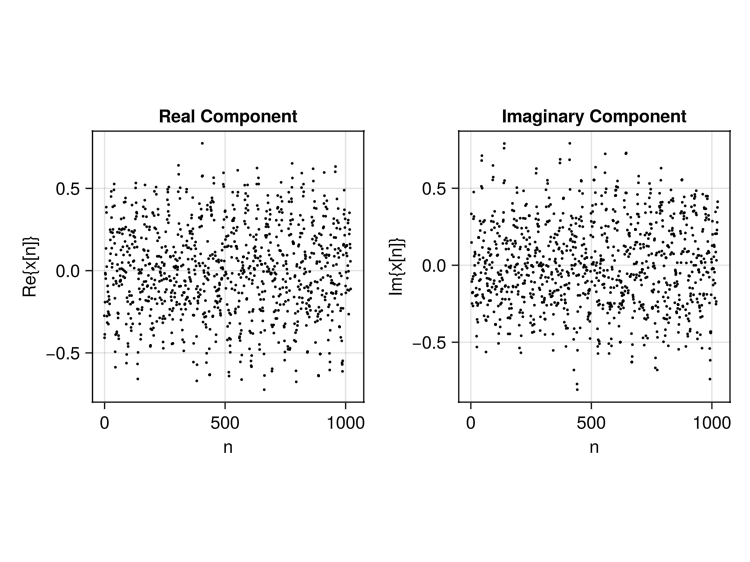

In [4]:
fig = Figure()
ax = Axis(fig[1,1],xlabel="n",ylabel="Re{x[n]}",title="Real Component",aspect=AxisAspect(1))
scatter!(ax,real.(sym),markersize=3,color=:black)
ax = Axis(fig[1,2],xlabel="n",ylabel="Im{x[n]}",title="Imaginary Component",aspect=AxisAspect(1))
scatter!(ax,imag.(sym),markersize=3,color=:black)
fig

In [5]:
PAPR_r = maximum(abs2.(real.(sym)))/mean(abs2.(real.(sym)))
PAPR_i = maximum(abs2.(imag.(sym)))/mean(abs2.(imag.(sym)))
PAPR = maximum(abs2.((sym)))/mean((abs2.(sym)));

In [6]:
PAPR_r,PAPR_i,PAPR

(7.645528812106259, 8.261846237637696, 5.080445410046699)

In [7]:
log2(sqrt(PAPR_r)),log2(sqrt(PAPR_i)),log2(sqrt(PAPR))

(1.4673081453789594, 1.5232321051235338, 1.17247749285859)

In [8]:
10*log10(PAPR_r),10*log10(PAPR_i),10*log10(PAPR)

(8.834075292823048, 9.170771080011486, 7.059017891826738)

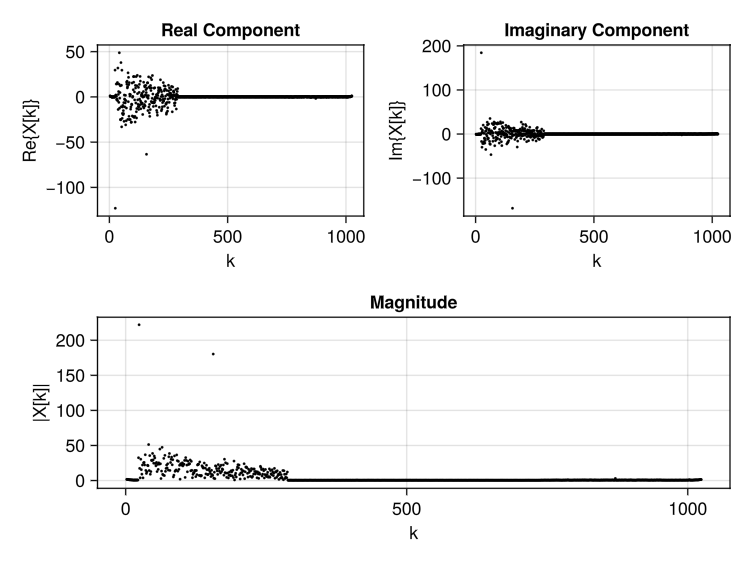

In [9]:
fig = Figure()
ax = Axis(fig[1,1],xlabel="k",ylabel="Re{X[k]}",title="Real Component")
scatter!(ax,real.(sym_fft),markersize=3,color=:black)
ax = Axis(fig[1,2],xlabel="k",ylabel="Im{X[k]}",title="Imaginary Component")
scatter!(ax,imag.(sym_fft),markersize=3,color=:black)
ax = Axis(fig[2,1:2],xlabel="k",ylabel="|X[k]|",title="Magnitude")
scatter!(ax,abs.(sym_fft),markersize=3,color=:black)
fig

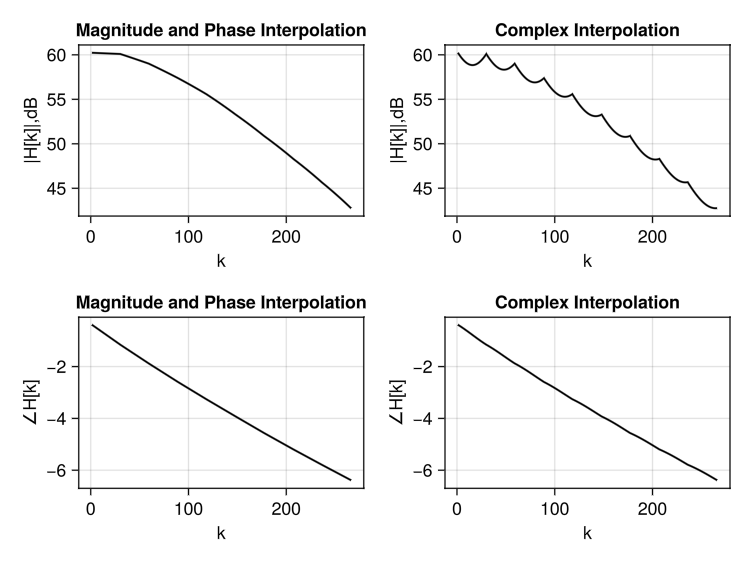

In [10]:
fig = Figure()
ax = Axis(fig[1,1],xlabel="k",ylabel="|H[k]|,dB",title="Magnitude and Phase Interpolation")
lines!(ax,20*log10.(abs2.(H[bins .> 0])),color=:black)
ax = Axis(fig[2,1],xlabel="k",ylabel="∠H[k]",title="Magnitude and Phase Interpolation")
lines!(ax,unwrap(angle.(H[bins .> 0])),color=:black)
ax = Axis(fig[1,2],xlabel="k",ylabel="|H[k]|,dB",title="Complex Interpolation")
lines!(ax,20*log10.(abs2.(H_[bins .> 0])),color=:black)
ax = Axis(fig[2,2],xlabel="k",ylabel="∠H[k]",title="Complex Interpolation")
lines!(ax,unwrap(angle.(H_[bins .> 0])),color=:black)
fig

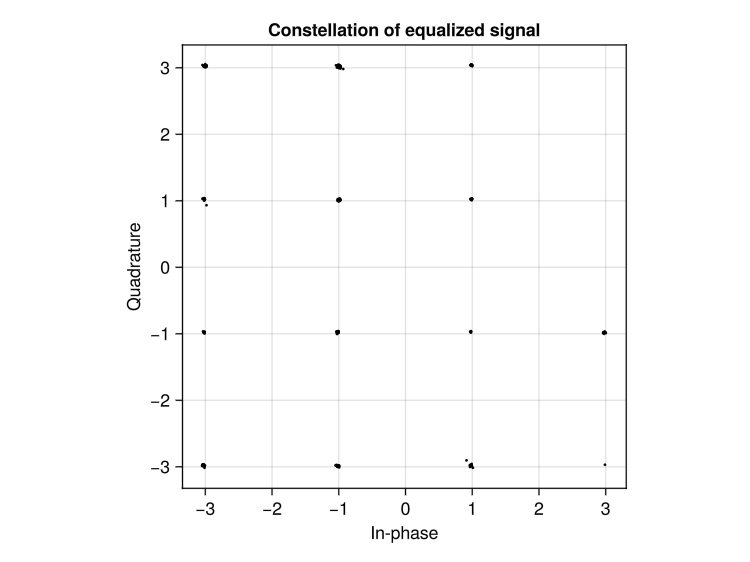

In [11]:
points = ifft(sym_fft[bins.==1]./H[bins.==1])*16*sqrt(10)
I = real(points)
Q = imag(points)
fig = Figure()
ax = Axis(fig[1,1],xlabel="In-phase",ylabel="Quadrature",title="Constellation of equalized signal",
    aspect=AxisAspect(1),xticks=-3:1:3,yticks=-3:1:3)
scatter!(ax,I,Q,markersize=3,color=:black)
fig

In [12]:


function int_to_bits_msb(x::Integer, n::Integer)
    return reverse(digits(x, base=2, pad=n))
end

function qam_gray_bitstring(points::AbstractVector{<:Complex}; M::Int = 16)

    L = Int(round(sqrt(M)))

    bits_per_axis = Int(round(log2(L)))

    levels = collect(-(L-1):2:(L-1))


    z = ComplexF64.(points)

    io = IOBuffer()

    for p in z
        # Nearest ideal level index on each axis (0-based)
        i_idx = argmin(abs2.(real(p) .- levels)) - 1
        q_idx = argmin(abs2.(imag(p) .- levels)) - 1

        # Binary index -> Gray code integer
        i_gray = i_idx ⊻ (i_idx >> 1)
        q_gray = q_idx ⊻ (q_idx >> 1)

        # Gray code integer -> MSB-first bit vectors
        i_bits = int_to_bits_msb(i_gray, bits_per_axis)
        q_bits = int_to_bits_msb(q_gray, bits_per_axis)

        # Append [I_bits..., Q_bits...]
        for b in i_bits
            print(io, b)
        end
        for b in q_bits
            print(io, b)
        end
    end

    return String(take!(io))
end


function bitstring_to_ascii(bits::AbstractString)
    return String([
        Char(parse(UInt8, bits[i:i+7], base=2))
        for i in 1:8:length(bits)
    ])
end


bitstring_to_ascii(qam_gray_bitstring(points,M=16))

"Lorem ipsum dolor sit amet, consectetur adipiscing elit. Maecenas dolor risus, luctus ut lorem non, pharetra blandit velit. Duis"

In [13]:
decision(x,L)=L[argmin(abs2.(real(x).-L))]+1im*L[argmin(abs2.(imag(x).-L))]
levels = collect(-(sqrt(MQAM)-1):2:(sqrt(MQAM)-1))
ds = map(x -> decision(x,levels),points)
EVM(X,X_hat) = sqrt(sum(abs2.(X-X_hat))/(sum(abs2.(X))))

EVM (generic function with 1 method)

In [14]:
EVM(ds,points), 20*log10(EVM(ds,points))

(0.007941922508952143, -42.001487095124574)